In [1]:
import os 
os.environ['JAX_JIT_PJIT_API_MERGE'] = '0'
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'gpu')


In [2]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


system = fluxonium_oscillator_system(
    computaional_states = '1,2',
    products_to_keep = [[ql, ol] for ql in [1,2] for ol in range(20) ] 
)


result = system.run_jax_gpu_solve(
    initial_state = system.truncate_function(qutip.basis(system.hilbertspace.dimension, 0)), 
    tlist  =  jnp.linspace(0,100, 100), 
    )

/home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qiskit_dynamics/dispatch/backends/jax.py:34: UserWarning: The functionality in the perturbation module of Qiskit Dynamics requires a JAX version <= 0.4.6, due to a bug in JAX versions > 0.4.6. For versions 0.4.4, 0.4.5, and 0.4.6, using the perturbation module functionality requires setting os.environ['JAX_JIT_PJIT_API_MERGE'] = '0' before importing JAX or Dynamics.
  warnings.warn(
2024-02-18 02:40:52.663394: W external/xla/xla/service/gpu/nvptx_compiler.cc:744] The NVIDIA driver's CUDA version is 12.0 which is older than the ptxas CUDA version (12.3.107). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
solving through chunks:  12%|█▏        | 12/100 [01:29<10:55,  7.45s/it]


KeyboardInterrupt: 

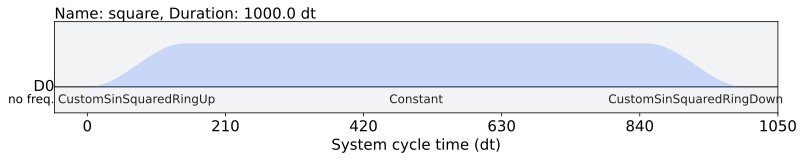

In [43]:


square = get_qiskit_square_pulse_with_sin_squared_edges(w_d,amp_without_2pi = 0.03, t_rise = 15,t_stop = 100)

            
result =solve_with_jax_gpu(
    ham_solver = ham_solver, 
    y0 = jnp.zeros(tot_dims).at[product_to_dressed[(0, 0)]].set(1).reshape(-1, 1), 
    tlist = tlist, 
    signals = square, 
    max_dt=1, 
    chunk_size=1

    )



result =solve_with_jax_gpu_lindbladian(ham_solver=ham_solver,
                    y0=psi0,
                    tlist=tlist,
                    signals=square,
                    chunk_size=0.01
                )

In [ ]:

# square.draw()
# from qiskit_dynamics.pulse import InstructionToSignals
# converter = InstructionToSignals(signal_sample_dt, carriers={"d0": carrier_freq})
# signals = converter.get_signals(square)
# fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))
# for ax, title in zip(axs, ["envelope", "signal"]):
#     signals[0].draw(0, tot_time, 2000, title, axis=ax)
#     ax.set_xlabel("Time (ns)")
#     ax.set_ylabel("Amplitude")
#     ax.set_title(title)

In [ ]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

TypeError: dot_general requires contracting dimensions to have the same shape, got (16,) and (256,).